In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Load clean data
df = pd.read_parquet("../data/processed/telco_clean.parquet")
df["churn_flag"] = (df["Churn"] == "Yes").astype(int)

# Overall profile
print(df.describe(include="all").T)
print("\nChurn rate:", df["churn_flag"].mean())

# Numeric distributions by churn
num = ["tenure", "MonthlyCharges", "TotalCharges"]
for c in num:
    print("\n", c)
    print(df.groupby("Churn")[c].agg(["mean", "median"]))

# Categorical churn rates
categorical = ["Contract", "InternetService", "PaymentMethod", "TechSupport", "OnlineSecurity"]
for c in categorical:
    print("\n", c)
    print(pd.crosstab(df[c], df["Churn"], normalize="index").round(3))

                   count unique                         top  freq  \
customerID          7043   7043                  3668-QPYBK     1   
Count             7043.0    NaN                         NaN   NaN   
Country             7043      1               United States  7043   
State               7043      1                  California  7043   
City                7043   1129                 Los Angeles   305   
Zip Code          7043.0    NaN                         NaN   NaN   
Lat Long            7043   1652      33.964131, -118.272783     5   
Latitude          7043.0    NaN                         NaN   NaN   
Longitude         7043.0    NaN                         NaN   NaN   
Gender              7043      2                        Male  3555   
SeniorCitizen       7043      2                          No  5901   
Partner             7043      2                          No  3641   
Dependents          7043      2                          No  5416   
tenure            7043.0    NaN   

C:\Users\Asitha Kodithuwakku\AppData\Local\Temp\ipykernel_10072\3375957316.py:7: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x='Contract', y='churn_flag', ci=None, palette='viridis')
C:\Users\Asitha Kodithuwakku\AppData\Local\Temp\ipykernel_10072\3375957316.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Contract', y='churn_flag', ci=None, palette='viridis')


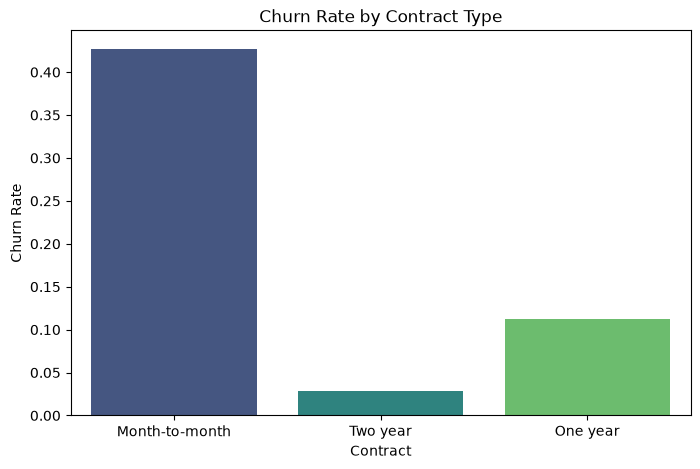

C:\Users\Asitha Kodithuwakku\AppData\Local\Temp\ipykernel_10072\3375957316.py:18: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x='tenure_cohort', y='churn_flag', ci=None, palette='mako')
C:\Users\Asitha Kodithuwakku\AppData\Local\Temp\ipykernel_10072\3375957316.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='tenure_cohort', y='churn_flag', ci=None, palette='mako')


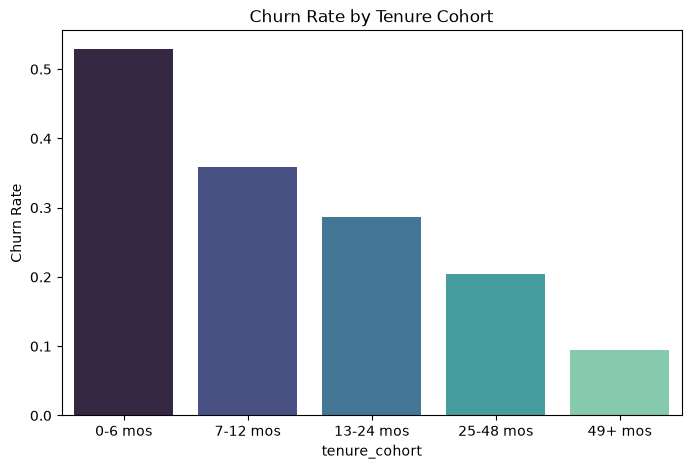

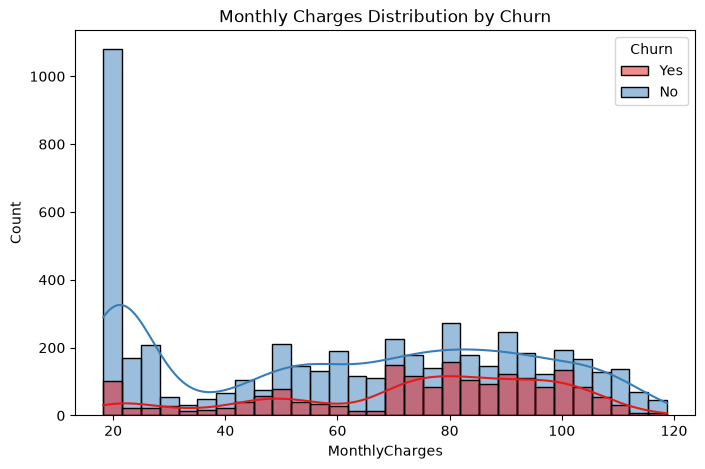

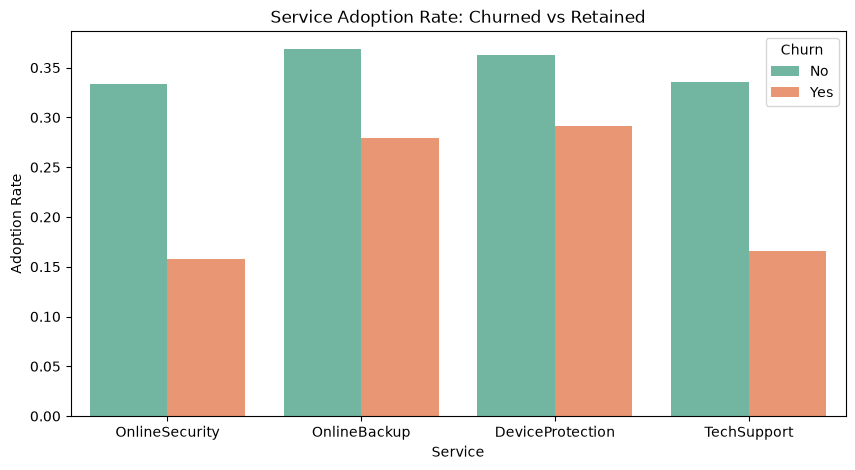

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Churn rate by contract type
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x='Contract', y='churn_flag', ci=None, palette='viridis')
plt.title('Churn Rate by Contract Type')
plt.ylabel('Churn Rate')
plt.show()

# 2. Churn rate by tenure cohort
bins = [-1, 6, 12, 24, 48, 100]
labels = ['0-6 mos', '7-12 mos', '13-24 mos', '25-48 mos', '49+ mos']
df['tenure_cohort'] = pd.cut(df['tenure'], bins=bins, labels=labels)

plt.figure(figsize=(8, 5))
sns.barplot(data=df, x='tenure_cohort', y='churn_flag', ci=None, palette='mako')
plt.title('Churn Rate by Tenure Cohort')
plt.ylabel('Churn Rate')
plt.show()

# 3. MonthlyCharges distribution split by churn
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='MonthlyCharges', hue='Churn', kde=True, bins=30, palette='Set1')
plt.title('Monthly Charges Distribution by Churn')
plt.show()

# 4. Service adoption rate for churned vs retained customers
services = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport']
# Convert 'Yes' to 1 and others to 0 for mean calculation
service_df = df[['Churn'] + services].copy()
for s in services:
    service_df[s] = (service_df[s] == 'Yes').astype(int)

service_melt = service_df.groupby('Churn')[services].mean().reset_index().melt(id_vars='Churn', var_name='Service', value_name='Adoption Rate')

plt.figure(figsize=(10, 5))
sns.barplot(data=service_melt, x='Service', y='Adoption Rate', hue='Churn', palette='Set2')
plt.title('Service Adoption Rate: Churned vs Retained')
plt.show()

### Business Findings

**Finding 1:** Churn rate differs by Contract type.
**Evidence:** Month-to-month churn rate is 42.7% vs Two-year churn rate of 2.8%[cite: 1].
**Interpretation:** This is an association, not proof of causation[cite: 1].
**Action:** Prioritize contract upgrade experiments[cite: 1].

**Finding 2:** Churn risk differs by tenure cohort.
**Evidence:** The 0-6 months cohort exhibits the highest churn rate, which sharply declines for the 49+ months cohort.
**Interpretation:** This is an association, indicating early customer lifecycles are highly volatile. 
**Action:** Prioritize early-tenure onboarding and check-in calls within the first 6 months.

**Finding 3:** The distribution of monthly charges differs by retention status.
**Evidence:** Churned customers have a higher median monthly charge ($79.65) compared to retained customers ($64.42).
**Interpretation:** This is an association, not proof that higher prices alone cause churn (it may correlate with specific service combinations).
**Action:** Review price sensitivity and consider targeted discounts for high-bill, month-to-month customers.

**Finding 4:** Churn rate differs by Tech Support adoption.
**Evidence:** Customers without Tech Support churn at 41.6%, while those with it churn at only 15.2%.
**Interpretation:** This is an association; customers who seek tech support may simply be more invested in the service.
**Action:** Bundle Tech Support into high-risk Month-to-Month plans for an A/B test.